# Applied Machine Learning (CSAI2017P) — Lab Assignment 3
## Time-Series Regression: Stock Price Prediction

Experiments 4 · CO2, CO4 · **10 marks**

| | |
|---|---|
| Name : EKTA BHARDWAJ
| SAP ID : 590022698
| Batch : 5


**Datasets:** C1 (daily stock OHLCV)

---

### Before you start
- Attempt **2 of 3** in Section A, **1 of 2** in Section B. Section C is compulsory.
- Fit every transformer inside a `Pipeline`. Never fit on the test set.
- Set `random_state` wherever the question asks for reproducibility.
- Every question wants a short written observation, not just a number.
- Restart the kernel and run top-to-bottom before you submit.


In [1]:
# Applied Machine Learning Lab - LA03
# Time-Series Regression: Stock Price Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

RANDOM_STATE = 0

## Load the data

Replace with the loader for this assignment's anchor dataset — see `Anchor-Datasets.pdf` for the snippets.

In [10]:
import yfinance as yf

df = yf.download("AAPL", start="2021-01-01", end="2026-01-01", auto_adjust=False)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2021-01-04,125.632507,129.410004,133.610001,126.760002,133.520004,143301900
2021-01-05,127.185776,131.009995,131.740005,128.429993,128.889999,97664900
2021-01-06,122.904533,126.599998,131.050003,126.379997,127.720001,155088000
2021-01-07,127.098427,130.919998,131.630005,127.860001,128.360001,109578200
2021-01-08,128.195480,132.050003,132.630005,130.229996,132.429993,105158200


In [2]:
# C1 Dataset — Daily stock OHLCV

ticker = "AAPL"

df = yf.download(
    ticker,
    start="2021-01-01",
    end="2026-01-01",
    auto_adjust=False
)

# Flatten columns if yfinance returns a MultiIndex
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Prepare the date column
df = df.reset_index()
df["Date"] = pd.to_datetime(df["Date"])

# Keep observations in chronological order
df = df.sort_values("Date").reset_index(drop=True)

print(f"Ticker: {ticker}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Number of trading days: {len(df)}")

display(df.head())

[*********************100%***********************]  1 of 1 completed

Ticker: AAPL
Date range: 2021-01-04 to 2025-12-31
Number of trading days: 1255


Price,Date,Adj Close,Close,High,Low,Open,Volume
0,2021-01-04,125.632507,129.410004,133.610001,126.760002,133.520004,143301900
1,2021-01-05,127.185776,131.009995,131.740005,128.429993,128.889999,97664900
2,2021-01-06,122.904533,126.599998,131.050003,126.379997,127.720001,155088000
3,2021-01-07,127.098427,130.919998,131.630005,127.860001,128.360001,109578200
4,2021-01-08,128.195480,132.050003,132.630005,130.229996,132.429993,105158200


Dataset Information
The analysis uses daily OHLCV observations for Apple Inc. (AAPL), obtained through Yahoo Finance using the yfinance library. The selected period provides more than three years of continuous trading-day observations, satisfying the dataset requirement for C1.

---

# Section A — attempt any 2 of 3 (2 marks each)

*attempt 2 of 3*

## A1. Load and describe the series  &nbsp;&nbsp;`[2 marks]`

*Dataset: C1, one ticker, ≥ 3 years.*

a. Load the daily history, parse the date column and sort ascending.
b. Plot the closing price and state the date range and number of trading days.
c. State in two lines why the row order matters here but did not in LA02.


Date range:
2021-01-04 to 2025-12-31

Number of trading days: 1255

First five observations:


Price,Date,Adj Close,Close,High,Low,Open,Volume
0,2021-01-04,125.632507,129.410004,133.610001,126.760002,133.520004,143301900
1,2021-01-05,127.185776,131.009995,131.740005,128.429993,128.889999,97664900
2,2021-01-06,122.904533,126.599998,131.050003,126.379997,127.720001,155088000
3,2021-01-07,127.098427,130.919998,131.630005,127.860001,128.360001,109578200
4,2021-01-08,128.195480,132.050003,132.630005,130.229996,132.429993,105158200



Last five observations:


Price,Date,Adj Close,Close,High,Low,Open,Volume
1250,2025-12-24,273.066711,273.809998,275.429993,272.200012,272.339996,17910600
1251,2025-12-26,272.657837,273.399994,275.369995,272.859985,274.160004,21521800
1252,2025-12-29,273.016876,273.760010,274.359985,272.350006,272.690002,23715200
1253,2025-12-30,272.338715,273.079987,274.079987,272.279999,272.809998,22139600
1254,2025-12-31,271.122009,271.859985,273.679993,271.750000,273.059998,27293600


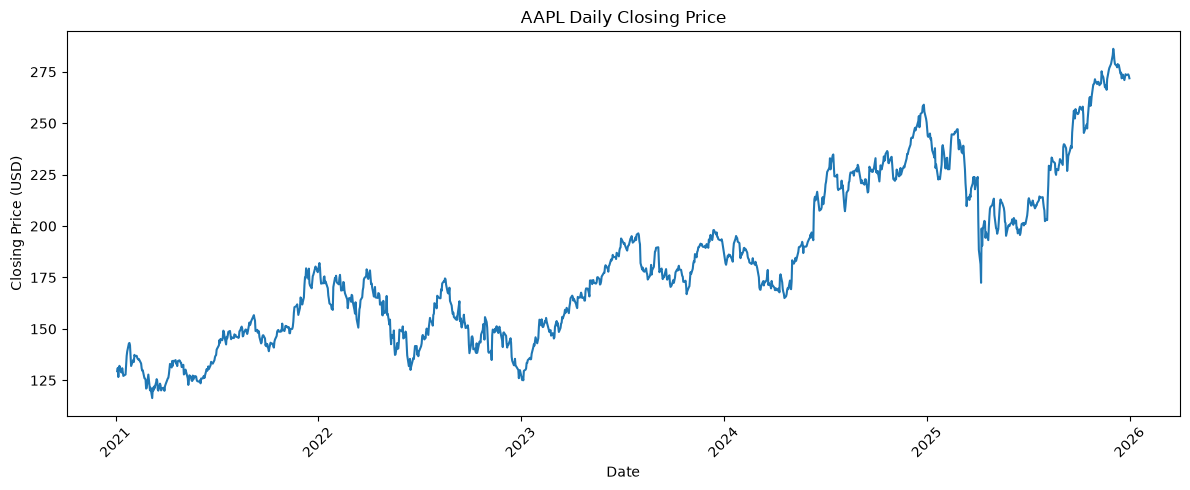

In [3]:
# A1 — Describe the time series

print("Date range:")
print(df["Date"].min().date(), "to", df["Date"].max().date())

print("\nNumber of trading days:", len(df))

print("\nFirst five observations:")
display(df.head())

print("\nLast five observations:")
display(df.tail())

# Closing price plot
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.title(f"{ticker} Daily Closing Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation A1(b):**

The AAPL dataset contains 1,255 trading-day observations from January 4, 2021, to December 31, 2025. The closing-price series provides a chronological view of AAPL’s price movement across the five-year period, making it suitable for time-series analysis and forecasting.

**Observation (A1)(c):**

The row order matters in AAPL data because each row represents a specific trading day, and the sequence reflects how the stock changes over time. In LA02, the observations were independent records, so their order could be changed without affecting the analysis.

## A2. Lag features  &nbsp;&nbsp;`[2 marks]`

*Dataset: C1.*

a. Create features `Close_lag1`, `Close_lag2`, `Close_lag3` and a 5-day rolling mean.
b. Set the target to the next day's close. Show the first five rows of the resulting frame.
c. Explain in two lines why the first few rows must be dropped.


In [4]:
# A2 — Create lag and rolling-window features

data = df.copy()

# Previous closing prices
data["Close_lag1"] = data["Close"].shift(1)
data["Close_lag2"] = data["Close"].shift(2)
data["Close_lag3"] = data["Close"].shift(3)

# Five-day rolling average
data["Close_rolling_mean_5"] = data["Close"].rolling(window=5).mean()

# Next day's closing price as prediction target
data["Target"] = data["Close"].shift(-1)

# Remove rows with unavailable lag/target values
data = data.dropna().reset_index(drop=True)

display(
    data[
        [
            "Date",
            "Close",
            "Close_lag1",
            "Close_lag2",
            "Close_lag3",
            "Close_rolling_mean_5",
            "Target"
        ]
    ].head()
)

Price,Date,Close,Close_lag1,Close_lag2,Close_lag3,Close_rolling_mean_5,Target
0,2021-01-08,132.050003,130.919998,126.599998,131.009995,129.998000,128.979996
1,2021-01-11,128.979996,132.050003,130.919998,126.599998,129.911998,128.800003
2,2021-01-12,128.800003,128.979996,132.050003,130.919998,129.470000,130.889999
3,2021-01-13,130.889999,128.800003,128.979996,132.050003,130.328000,128.910004
4,2021-01-14,128.910004,130.889999,128.800003,128.979996,129.926001,127.139999


**Observation (A2):**

Lag features use previous trading-day prices to provide historical information for predicting the next day’s closing price. The first few rows are removed because sufficient past observations are not available to calculate all lag and rolling features.

---

# Section B — attempt any 1 of 2 (4 marks each)

*attempt 1 of 2*

## B1. Random split versus chronological split  &nbsp;&nbsp;`[4 marks]`

*Dataset: C1.*

a. Train a `RandomForestRegressor` twice: once with `train_test_split(shuffle=True)`, once with the last 20% of dates held out.
b. Report test MAE for both and put them side by side.
c. Explain in 6–8 lines why the shuffled number is meaningless, naming the mechanism.


In [5]:
# B1 — Define predictor variables and target

features = [
    "Close_lag1",
    "Close_lag2",
    "Close_lag3",
    "Close_rolling_mean_5"
]

X = data[features]
y = data["Target"]

print("Features used:")
print(features)

print("\nNumber of observations:", len(data))

Features used:
['Close_lag1', 'Close_lag2', 'Close_lag3', 'Close_rolling_mean_5']

Number of observations: 1250


In [6]:
# B1(a) — Randomized train-test split

X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=True,
    random_state=RANDOM_STATE
)

random_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

random_model.fit(X_train_random, y_train_random)

random_pred = random_model.predict(X_test_random)

random_mae = mean_absolute_error(
    y_test_random,
    random_pred
)

print(f"Randomized split MAE: {random_mae:.4f}")

Randomized split MAE: 3.6653


In [7]:
# B1(b) — Chronological train-test split

split_index = int(len(data) * 0.80)

train_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]

X_train_time = train_data[features]
y_train_time = train_data["Target"]

X_test_time = test_data[features]
y_test_time = test_data["Target"]

time_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

time_model.fit(X_train_time, y_train_time)

time_pred = time_model.predict(X_test_time)

time_mae = mean_absolute_error(
    y_test_time,
    time_pred
)

print(f"Chronological split MAE: {time_mae:.4f}")

Chronological split MAE: 9.1672


In [8]:
# B1 — Compare evaluation strategies

comparison = pd.DataFrame({
    "Evaluation Strategy": [
        "Randomized split",
        "Chronological split"
    ],
    "Test MAE": [
        random_mae,
        time_mae
    ]
})

comparison["Test MAE"] = comparison["Test MAE"].round(4)

display(comparison)

,Evaluation Strategy,Test MAE
0,Randomized split,3.6653
1,Chronological split,9.1672


**Observation (B1):**

The randomized split gives a lower test MAE of 3.6653, while the chronological split gives a higher MAE of 9.1672. However, the randomized result is not reliable for this time-series problem because it mixes observations from different points in time between the training and test sets. This can allow information from later periods to influence the model while predicting earlier periods. This issue is known as temporal leakage or data leakage. A chronological split is more realistic because the model is trained only on past observations and tested on future observations. Therefore, the chronological MAE provides a more meaningful estimate of forecasting performance.

---

# Section C — compulsory (2 marks)

*compulsory*

## C1. Would you trade on it?  &nbsp;&nbsp;`[2 marks]`

*Dataset: C1.*

a. Convert your best model's predictions into an up/down direction call and report directional accuracy.
b. In 4–6 lines, state whether a low MAE with near-50% directional accuracy is useful, and why.


In [9]:
# C1 — Directional accuracy

# Actual direction: whether the next close increased
actual_direction = (
    test_data["Target"].to_numpy()
    > test_data["Close"].to_numpy()
)

# Predicted direction from the chronological model
predicted_direction = (
    time_pred
    > test_data["Close"].to_numpy()
)

directional_accuracy = np.mean(
    actual_direction == predicted_direction
)

print(
    f"Directional Accuracy: "
    f"{directional_accuracy * 100:.2f}%"
)

Directional Accuracy: 47.60%


**Observation (C1):**

A low MAE indicates that the model’s predicted prices may be numerically close to the actual closing prices, but this does not necessarily mean that it can correctly predict the direction of price movement. In this experiment, the directional accuracy is 47.60%, which is close to 50%. This suggests that the model has limited ability to identify whether the stock price will rise or fall. Therefore, a low MAE alone would not be sufficient to consider the model useful for trading decisions.